# Overview (Donor)

The second phase of data wrangling focused on donor variables and recipient sex stratification. Exploratory visualizations were used to assess feature distributions, identify data quality issues, and support data cleaning. Shadow variables were created to track missingness across features and facilitate examination of missing-data patterns. This process improved understanding of feature behavior and data completeness, informing subsequent informative-missingness testing, imputation, and modeling decisions.

In [1]:
# path to user functions
import sys  
sys.path.append('../modules/')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# set seaborn theme
sns.set_theme()

# python modules
import heart_utilities as u
import heart_plot as plot
import heart_imputation_diagnose as hid

# initializing variables
SEED = 1776

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

## Import Data

In [2]:
# import data
df = pd.read_parquet("../Data/DON_Heart_Data.parquet")
df_dict = pd.read_parquet("../Data/Dict_main.parquet")
# display 
df.head()

,DeceasedRetyped_DON,AntigenDA1_DON,AntigenDA2_DON,AntigenDB1_DON,AntigenDB2_DON,AntigenDDR1_DON,AntigenDDR2_DON,Citizenship_DON,PastCocaineUse_DON,Age_DON,Ethnicity_DON,Hepatitis_B_CoreAntibody_DON,SurfaceAntigenHEP_B_DON,BloodGroup_DON,HeavyAlcoholUse_DON,DeceasedOrLiving_DON,Gender_DON,ResidencyState_DON,Antibody_HEP_C_DON,NonHeartBeating_DON,AntiHypertensive_DON,BloodInfectionSource_DON,BloodUreaNitrogenLevel_DON,Creatinine_DON,OtherInfectionSource_DON,Diuretics_DON,SteroidsUse_DON,TriiodothyronineT3_DON,ThyroxineT4_DON,OtherMedsText2_DON,OtherMedsText3_DON,OtherMedsText1_DON,PulmonaryInfection_DON,PULM_INF_CONF_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,TerminalTotalBilirubin_DON,UrineInfection_DON,Vasodilators_DON,AntibodyResultRPR_VDRL_DON,InfectionClinical_DON,CocaineUse_DON,OtherDrugUse_DON,CancerExtraCranial_DON,CancerSite_DON,CigaretteHistory_DON,HypertensionHistory_DON,CancerIntraCranial_DON,CancerHistory_DON,DiabetesHistory_DON,Diabetes_DON,PastOtherDrugUse_DON,CancerSkin_DON,SerologyAntiCMV_DON,CauseOfDeath_DON,SyntheticAntiDiureticHormone_DON,DeathCircumstance_DON,DeathMechanism_DON,HeparinManagement_DON,ArginnieManagement_DON,InsulinManagement_DON,Height_cm_DON,Weight_kg_DON,BMI_Donation_DON,HBV_NAT_Result_DON,HCV_NAT_Result_DON,HIV_NAT_Result_DON,IschemicTimeHour_DON,AllocationType_DON,UrineProtein_DON,CardiacArrest_DON,LungPO2_DON,MyocardialInfarctionHistory_DON,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_DON,CoronaryAngiogram_DON,Biopsy_DON,Tatoos_DON,AntibodyResultHBSAB_DON,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,HIV_Risk_DON,InotropicAgent_DON,KidneyAllocation_DON,InotropicMedicationProcurement_DON,TransfusionNumber_DON,LungPO2_Done_DON,LungPO2_FIO2_DON,OrganRecovery_PCO2_DON,PulmonaryCatheter_DON,BronchoscopyLeft_DON,BronchoscopyRight_DON,ChestXray_DON,BloodPH_DON,Hematocrit_DON,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel
0,No,2,29,44,49,4,15,US Citizen,No,31,Black,Negative,Negative,A,No,Deceased Donor,M,CA,Negative,No,Yes,No,18.0,1.30,No,Yes,No,No,No,"KCL,","DOPAMINE, VASOPRESSIN,","ZOSYN, VANCOMYCIN",Yes,Yes,46.0,40.0,0.4,No,No,Negative,Yes,Unknown,Unknown,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,Yes,HOMICIDE,GUNSHOT WOUND,Yes,No,Yes,172.7,107.0,35.867286,Unknown,Unknown,Unknown,4.9,Local,No,No,182.0,No,Echo,60.0,No,Biopsy not done,Yes,Not Done,Positive,Negative,No,Unknown,No,No,1 - 5,Yes,47.0,40.0,No,Normal,Normal,Abnormal-right,7.38,26.2,329.0,No,2,2,1,5,Identical
1,Yes,2,68,49,60,10,16,Non-US Citizen/US Resident,No,30,Hispanic,Negative,Negative,O,No,Deceased Donor,M,TX,Negative,No,No,No,29.0,0.70,No,Yes,No,No,Yes,<NA>,<NA>,"ANCEF, FENTANYL, VERSED,LASIX",Yes,Yes,38.0,171.0,0.8,No,No,Negative,Yes,Unknown,Unknown,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,No,"Accident, Non-MVA",BLUNT INJURY,Yes,Yes,No,172.7,67.1,22.492476,Unknown,Unknown,Unknown,3.1,Local,No,No,323.0,No,Echo,55.0,No,Biopsy not done,No,Not Done,Positive,Negative,No,Dopamine,No,Yes,6 - 10,Yes,100.0,28.0,No,Normal,Normal,Abnormal-left,7.50,27.8,2592.0,Yes,1,2,2,5,Identical
2,No,2,3,7,44,11,15,US Citizen,No,15,"White, Non-Hispanic",Negative,Negative,O,No,Deceased Donor,M,NY,Negative,No,No,No,15.0,0.74,No,Yes,Yes,No,Yes,"AMPHOTERICIN, BETADINE",ZANTAC,"ZOSYN, VANCOMYCIN",Yes,Yes,445.0,217.0,0.7,No,No,Negative,Yes,Unknown,Yes,No,NO,No,No,No,No,No,No,Yes,No,Negative,ANOXIA,No,NONE OF THE ABOVE,DRUG INTOXICATION,Yes,Yes,No,170.0,59.0,20.415225,Unknown,Unknown,Unknown,1.4,Local,No,No,401.0,No,Echo,60.0,No,Biopsy not done,No,Not Done,Negative,Negative,No,"Other, specify",No,Yes,NONE,Yes,100.0,41.0,No,Normal,Unknwn,Abnormal-both,7.40,25.4,2913.0,Yes,0,1,2,3,Identical
3,Yes,33,68,39,51,1,8,US Citizen,No,47,"White, Non-Hispanic",Negative,Negative,A1,No,Deceased Donor,F,NY,Negative,No,Yes,Yes,29.0,1.34,No,Yes,Yes,No,Yes,"D50, DOPAMINE, DIFLUCAN",<NA>,"KCL, VANCO, MAG, ZOSYN",Yes,Yes,248.0,165.0,0.3,Yes,No,Negative,Yes,Unknown,Y

In [3]:
df.info(show_counts=True, max_cols=df.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 102 columns):
 #    Column                              Non-Null Count  Dtype   
---   ------                              --------------  -----   
 0    DeceasedRetyped_DON                 30300 non-null  category
 1    AntigenDA1_DON                      30300 non-null  category
 2    AntigenDA2_DON                      30300 non-null  category
 3    AntigenDB1_DON                      30300 non-null  category
 4    AntigenDB2_DON                      30300 non-null  category
 5    AntigenDDR1_DON                     30300 non-null  category
 6    AntigenDDR2_DON                     30300 non-null  category
 7    Citizenship_DON                     30300 non-null  category
 8    PastCocaineUse_DON                  30300 non-null  category
 9    Age_DON                             30300 non-null  int64   
 10   Ethnicity_DON                       30300 non-null  category
 11   Hepatitis_B_CoreAntibody

## Combine Meds

In [4]:
# select column name
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
cols = sorted(cols)
df[cols].sample(n=10, random_state=SEED)

,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
24714,<NA>,<NA>,<NA>
12770,"ZOSYN,MICAFUNGIN",VANCOMYCIN,VECURONIUM
12524,"VANCOMYCIN,ZOSYN",ROCURONIUIM,ALBUMIN
14592,"ALBUTEROL, ZOSYN, VANCO","CEFEPIME, ROCURONIUM",<NA>
15126,"ALBUTEROL,ZOSYN",VANCOMYCIN,"ROCURONIUM,NEOSYNEPHRINE"
153,"ZOSYN, ALBUTEROL, DOBUTAMINE,",<NA>,<NA>
10572,VANCOMYCIN,"ROCURONIUM, FENTANYL",<NA>
16252,"CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE,","VANCOMYCIN, ROCURONIUM",<NA>
25908,ROCURONIUM,NARCAN,VANCOMYCIN
3987,ZOSYN,VANCOMYCIN,ALBUTEROL


In [5]:
df["Meds_DON"] = (
    df[cols].fillna("")
    .agg(", ".join, axis=1)

    # Normalize separators: convert ., /, ;, : to commas
    .str.replace(r"[./;:]", ",", regex=True)

    # Fix double commas
    .str.replace(r",\s*,", ",", regex=True)

    # Normalize comma spacing (remove spaces before/after)
    .str.replace(r"\s*,\s*", ", ", regex=True)

    # Strip trailing commas/spaces
    .str.strip(", ")
)
df["Meds_DON"].sample(n=10, random_state=SEED)

24714                                                                  
12770                         ZOSYN, MICAFUNGIN, VANCOMYCIN, VECURONIUM
12524                           VANCOMYCIN, ZOSYN, ROCURONIUIM, ALBUMIN
14592                     ALBUTEROL, ZOSYN, VANCO, CEFEPIME, ROCURONIUM
15126           ALBUTEROL, ZOSYN, VANCOMYCIN, ROCURONIUM, NEOSYNEPHRINE
153                                        ZOSYN, ALBUTEROL, DOBUTAMINE
10572                                  VANCOMYCIN, ROCURONIUM, FENTANYL
16252    CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE, VANCOMYCIN, ROCURONIUM
25908                                    ROCURONIUM, NARCAN, VANCOMYCIN
3987                                       ZOSYN, VANCOMYCIN, ALBUTEROL
Name: Meds_DON, dtype: str

In [6]:
def dedupe_meds(x):
    parts = [p.strip() for p in x.split(",") if p.strip()]
    seen = set()
    unique = []
    for med in parts:
        key = med.upper()
        if key not in seen:
            seen.add(key)
            unique.append(med)
    return ", ".join(unique)

df["Meds_DON"] = df["Meds_DON"].apply(dedupe_meds)
# new feature
df["Meds_DON"].sample(n=10, random_state=SEED)

24714                                                                  
12770                         ZOSYN, MICAFUNGIN, VANCOMYCIN, VECURONIUM
12524                           VANCOMYCIN, ZOSYN, ROCURONIUIM, ALBUMIN
14592                     ALBUTEROL, ZOSYN, VANCO, CEFEPIME, ROCURONIUM
15126           ALBUTEROL, ZOSYN, VANCOMYCIN, ROCURONIUM, NEOSYNEPHRINE
153                                        ZOSYN, ALBUTEROL, DOBUTAMINE
10572                                  VANCOMYCIN, ROCURONIUM, FENTANYL
16252    CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE, VANCOMYCIN, ROCURONIUM
25908                                    ROCURONIUM, NARCAN, VANCOMYCIN
3987                                       ZOSYN, VANCOMYCIN, ALBUTEROL
Name: Meds_DON, dtype: str

In [7]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

In [8]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

## Gender

In [9]:
# any nans
u.any_nans(df)

╭──────────────────────────── Total Rows: 30,300 ────────────────────────────╮
│  ⚠ Missing Values Found                                                    │
│  ───────────────────────────────────────────────────────                   │
│     Column                                Null Count        Percentage     │
│     IschemicTimeHour_DON                         216           0.7129%     │
│     LungPO2_FIO2_DON                             186           0.6139%     │
│     LungPO2_DON                                  108           0.3564%     │
│     OrganRecovery_PCO2_DON                        83           0.2739%     │
│     BloodPH_DON                                   77           0.2541%     │
│     Level_SGOT_AST_DON                            58           0.1914%     │
│     Level_SGOT_ALT_DON                            58           0.1914%     │
│     TerminalTotalBilirubin_DON                    57           0.1881%     │
│     BloodUreaNitrogenLevel_DON                    54           0.1782%     │
│     Creatinine_DON                                54           0.1782%     │
│     Hematocrit_DON                                53           0.1749%     │
│     LV_EjectionFractionPercent_DON                34           0.1122%     │
│     BMI_Donation_DON                               9           0.0297%     │
│     Weight_kg_DON                                  3           0.0099%     │
╰────────────────────────────────────────────────────────────────────────────╯

In [10]:
df.Gender_DON.value_counts(dropna=False)

Gender_DON
M    21366
F     8934
Name: count, dtype: int64

In [11]:
df_m = df[df.Gender_DON == 'M'].copy()
df_f = df[df.Gender_DON == 'F'].copy()
#
df_m.shape, df_f.shape

((21366, 100), (8934, 100))

## Medication

* **Zosyn** (piperacillin/tazobactam) is a powerful, hospital-grade intravenous antibiotic combination used to treat severe bacterial infections, including pneumonia, intra-abdominal infections, and skin infections. It works by combining piperacillin, a penicillin-class antibiotic, with tazobactam, which protects piperacillin from degradation, allowing it to kill bacteria.
* **Rocuronium** (brand name Zemuron) is an intermediate-acting, nondepolarizing neuromuscular blocking agent (paralytic) used during surgery or critical care. It is administered intravenously as an adjunct to general anesthesia to relax skeletal muscles, facilitating rapid sequence and routine tracheal intubation.
* **Vancomycin** is a powerful glycopeptide antibiotic used to treat severe, resistant gram-positive bacterial infections, including MRSA and C. difficile. It works by inhibiting bacterial cell wall synthesis, making it a bactericidal agent. It is administered intravenously for systemic infections and orally for gut-specific infections.
* **Albuterol** is a fast-acting bronchodilator (short-acting beta2-agonist) used to open airways in the lungs, commonly known as a "rescue inhaler" for asthma and COPD. It treats wheezing and breathing difficulties by relaxing airway muscles.
* **Ancef (cefazolin)** is a first-generation cephalosporin antibiotic used to treat various bacterial infections—including skin, bone, joint, and urinary tract infections—and is commonly given intravenously before surgery to prevent infections. It works by inhibiting bacterial cell wall synthesis.
* **Neo-Synephrine** (phenylephrine) is a medication used primarily as a nasal decongestant to temporarily relieve a stuffy nose and sinus pressure from colds, allergies, and hay fever. It works as a vasoconstrictor, narrowing blood vessels in the nasal passages to reduce swelling and improve breathing.
* **Vecuronium** (brand name: Norcuron) is a non-depolarizing neuromuscular blocking agent used to produce skeletal muscle relaxation during surgery, tracheal intubation, or mechanical ventilation. It works by blocking nerve signals to muscles, resulting in temporary paralysis, but it does not cause sedation.
* **Levophed** (norepinephrine bitartrate) is a potent vasopressor medication used in emergency settings to treat severe, acute low blood pressure (hypotension) by rapidly constricting blood vessels and increasing blood pressure. It is administered via intravenous (IV) infusion in critical care, often in conditions like septic shock
* **KCl** (Potassium chloride) is an electrolyte supplement used to prevent or treat low blood potassium levels (hypokalemia), often caused by diuretics or illnesses. It supports heart, muscle, and nerve function, available as oral tablets/powders or IV.
* **Cefepime** is a fourth-generation, broad-spectrum cephalosporin antibiotic used to treat severe infections, including pneumonia, urinary tract infections, and febrile neutropenia. It acts by inhibiting bacterial cell wall synthesis and is effective against Gram-positive and Gram-negative bacteria, including Pseudomonas aeruginosa. Administered via IV or intramuscular injection, it is generally well-tolerated.
* **Fentanyl** is a potent synthetic opioid drug approved by the Food and Drug Administration for use as an analgesic (pain relief) and an anesthetic.
* **Albumin** (human) injection is a sterile, liquid protein solution derived from human plasma used to treat low blood volume (hypovolemia), shock, and low albumin levels (hypoalbuminemia). It increases blood pressure and plasma volume while reducing fluid leakage into tissues (edema); it is commonly used in critical care, major surgeries, burns, and liver disease.
* **Dopamine** is a critical neurotransmitter and hormone that functions as the brain's "feel-good" messenger, driving reward, motivation, memory, and motor control. Produced in the brain, it reinforces pleasurable behaviors and helps regulate focus.
* **Phenylephrine** is an alpha-1 adrenergic receptor agonist (drug class) used primarily as a nasal decongestant (oral/nasal) and to treat hypotension (injection). It acts by constricting blood vessels, thereby reducing nasal congestion and raising blood pressure. However, the FDA has proposed removing oral phenylephrine due to a lack of efficacy.
* **DuoNeb** (ipratropium bromide and albuterol sulfate) is a prescription inhalation solution used to treat reversible airway obstruction, specifically for COPD, chronic bronchitis, and emphysema. It acts as a bronchodilator, relaxing airway smooth muscle, reducing mucus, and improving breathing. It is administered via a nebulizer, generally four times a day.

### Male

In [12]:
# NaN check
df_m.Meds_DON.isna().any()

np.False_

In [13]:
u.get_top_frequencies(df_m, 'Meds_DON', top_n=10, sep=",")

╭─ Meds_DON ───────────────────────────────────────────────────────────────╮
│                                                                          │
│  Frequency Distribution Ranking                                          │
│  Total Exploded Occurrences: 107,879                                     │
│                                                                          │
│     Rank      Categorical Item              Frequency      Share (%)     │
│      #1       ZOSYN                             9,836          9.12%     │
│      #2       ROCURONIUM                        6,380          5.91%     │
│      #3       VANCOMYCIN                        5,665          5.25%     │
│      #4       ALBUTEROL                         4,431          4.11%     │
│      #5       ANCEF                             4,425          4.10%     │
│      #6       NEOSYNEPHRINE                     3,981          3.69%     │
│      #7       LEVOPHED                          3,799          3.52%     │
│      #8       VECURONIUM                        3,768          3.49%     │
│      #9       KCL                               2,968          2.75%     │
│     #10       CEFEPIME                          2,258          2.09%     │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

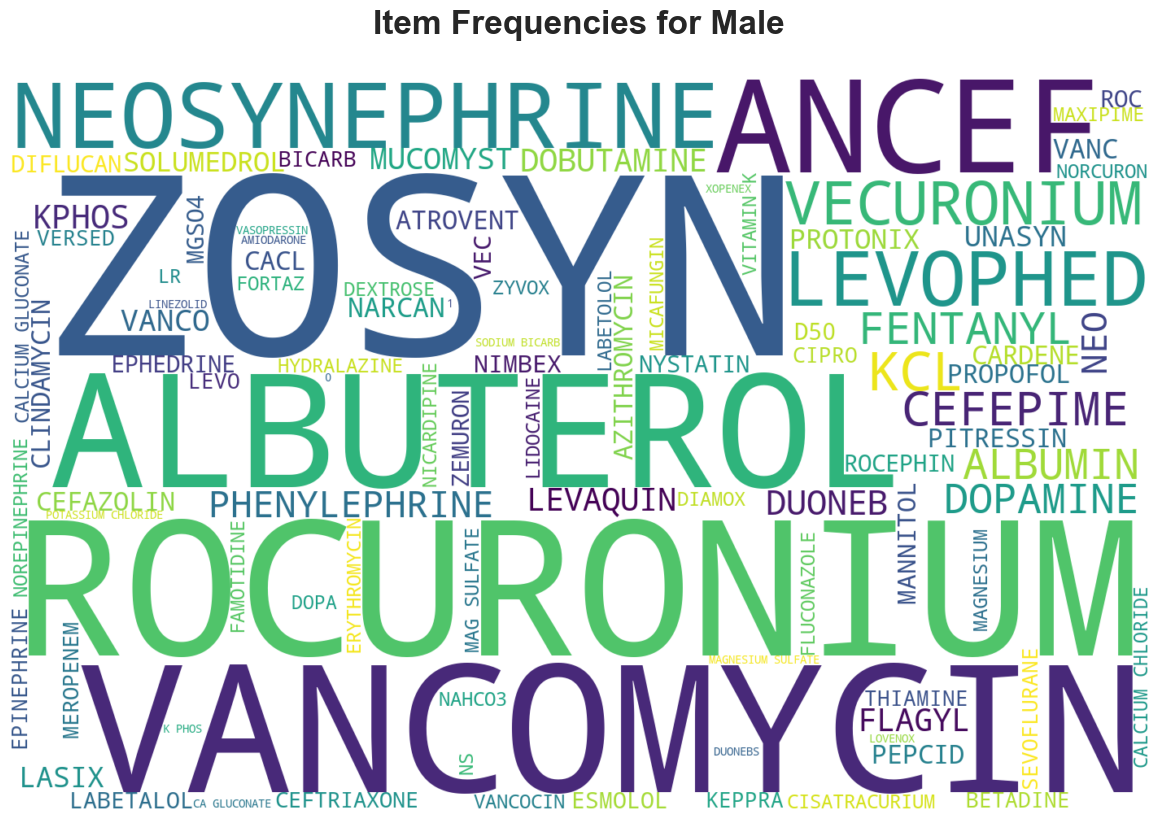

In [14]:
plot.plot_item_wordcloud(df_m.Meds_DON, title="Item Frequencies for Male", bg_color="white")

### Female

In [15]:
# NaN check
df_f.Meds_DON.isna().any()

np.False_

In [16]:
u.get_top_frequencies(df_f, 'Meds_DON', top_n=10, sep=",")

╭─ Meds_DON ───────────────────────────────────────────────────────────────╮
│                                                                          │
│  Frequency Distribution Ranking                                          │
│  Total Exploded Occurrences: 44,623                                      │
│                                                                          │
│     Rank      Categorical Item              Frequency      Share (%)     │
│      #1       ZOSYN                             3,866          8.66%     │
│      #2       ROCURONIUM                        2,559          5.73%     │
│      #3       VANCOMYCIN                        2,271          5.09%     │
│      #4       ALBUTEROL                         1,908          4.28%     │
│      #5       ANCEF                             1,803          4.04%     │
│      #6       NEOSYNEPHRINE                     1,731          3.88%     │
│      #7       VECURONIUM                        1,588          3.56%     │
│      #8       LEVOPHED                          1,568          3.51%     │
│      #9       KCL                               1,360          3.05%     │
│     #10       CEFEPIME                            979          2.19%     │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

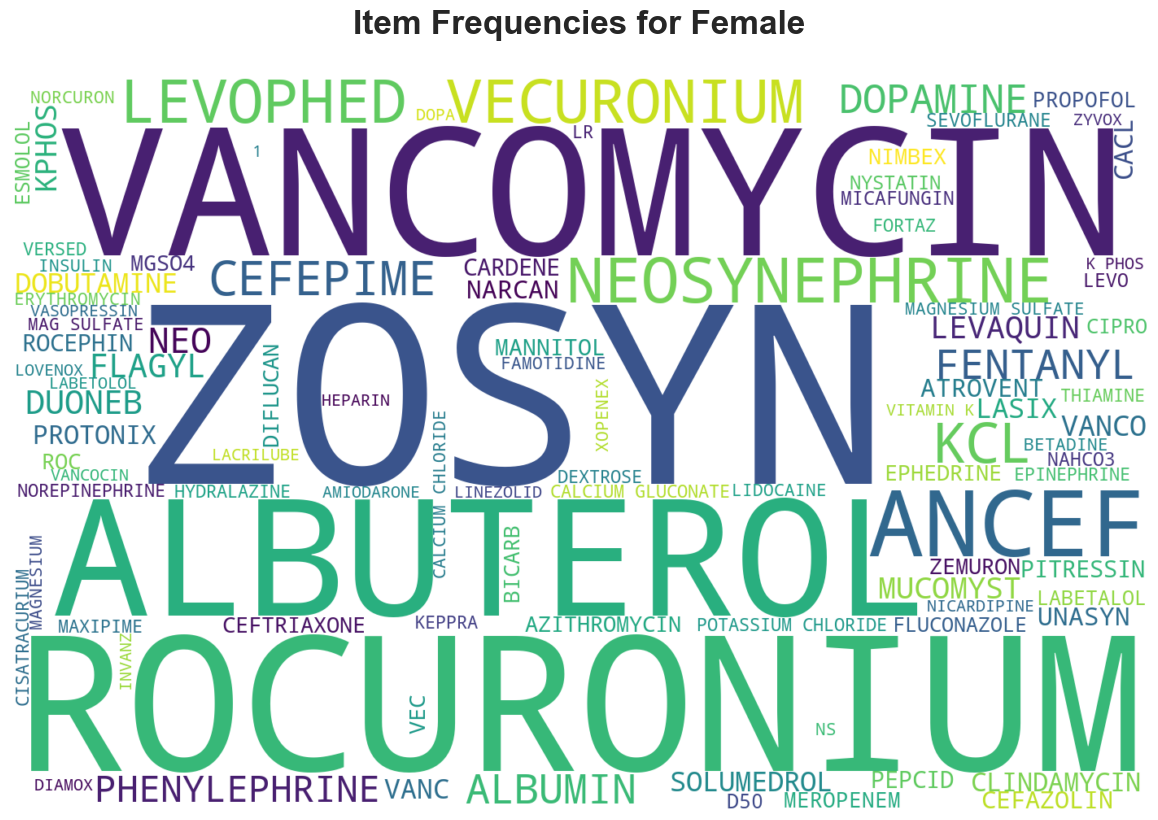

In [17]:
plot.plot_item_wordcloud(df_f.Meds_DON, title="Item Frequencies for Female", bg_color="white")

In [24]:
import importlib
importlib.reload(cc)

<module 'collinearity_check' from '/Users/sir/Desktop/Project/UNOS_GenderStratification/notebook/../modules/collinearity_check.py'>

In [28]:
import collinearity_check as cc
results = cc.compute_collinearity(df_f)

In [31]:
cc.summarise_collinearity(results).head(10)

,type,var1,var2,value,severity,pair_type,recommended_action
0,VIF,Weight_kg_DON,—,116.5351,Severe,numeric,Drop or transform variable
1,VIF,BMI_Donation_DON,—,105.0207,Severe,numeric,Drop or transform variable
2,VIF,Height_cm_DON,—,13.7936,Severe,numeric,Drop or transform variable
3,Cramér's V,DeceasedOrLiving_DON,Antibody_HEP_C_DON,1.0000,High,categorical-categorical,Consider dropping one variable
4,Cramér's V,DeceasedOrLiving_DON,NonHeartBeating_DON,1.0000,High,categorical-categorical,Consider dropping one variable
5,Cramér's V,DeceasedOrLiving_DON,BloodInfectionSource_DON,1.0000,High,categorical-categorical,Consider dropping one variable
6,Cramér's V,DeceasedOrLiving_DON,PulmonaryInfection_DON,1.0000,High,categorical-categorical,Consider dropping one variable
7,Cramér's V,DeceasedOrLiving_DON,UrineInfection_DON,1.0000,High,categorical-categorical,Consider dropping one variable
8,Cramér's V,DeceasedOrLiving_DON,CauseOfDeath_DON,1.0000,High,categorical-categorical,Consider dropping one variable
9,Cramér's V,DeceasedOrLiving_DON,KidneyAllocation_DON,1.0000,High,categorical-categorical,Consider dropping one variable


In [ ]:
a

In [ ]:
cc.summarise_collinearity(df_m)

## IschemicTimeHour
* [Determining optimal donor heart ischemic times in adult cardiac transplantation](https://onlinelibrary.wiley.com/doi/full/10.1111/jocs.16558)
* [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without a blood supply before significant damage occurs is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [ ]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    sns.despine(left=False, bottom=False, right=True, top=True)
    plt.tight_layout()
    plt.show()


def prepare_feature_cox(df_m, df_f, feature,
                         male_indicator=True,
                         female_indicator=True):
    """
    Cox-only preparation for one feature.
    
    Parameters
    ----------
    male_indicator   : True if male missingness is informative
    female_indicator : True if female missingness is informative
    
    Returns
    -------
    df_m_cox, df_f_cox
    """
    df_m_out = df_m.copy()
    df_f_out = df_f.copy()

    # Male
    if male_indicator:
        df_m_out[f'{feature}_IsMissing'] = (
            df_m_out[feature].isna().astype(int)
        )
    df_m_out[feature] = df_m_out[feature].fillna(
        df_m_out[feature].median()
    )

    # Female
    if female_indicator:
        df_f_out[f'{feature}_IsMissing'] = (
            df_f_out[feature].isna().astype(int)
        )
    df_f_out[feature] = df_f_out[feature].fillna(
        df_f_out[feature].median()
    )

    return df_m_out, df_f_out

### Male

In [ ]:
# info
features = u.get_feature_info(df, 'IschemicTimeHour_DON', cat=False)
# plot
plot_histogram(df_m, features[0], txt='Male: Ischemic Time Hour(s)', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'IschemicTimeHour_DON', cat=False)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f,  features[0], txt='Female')

#### 📌 Note:

> The female cohort demonstrated evidence of informative missingness: recipients with unrecorded donor ischemic times ($n = 51$) experienced a clinically meaningful baseline survival deficit of approximately 332 days compared to the complete-case cohort. Although the standardized effect size was small (Cohen's $d = −0.287$), its 95% confidence interval strictly excluded zero ($[−0.56, −0.01]$), justifying the retention of a female-specific missingness indicator. However, given the small sample size of the missing cohort and an upper confidence bound approaching zero, the true population effect may range from negligible to moderately adverse.

> In contrast, the male cohort exhibited a much smaller raw survival discrepancy (−123 days) with a negligible, non-significant effect size (Cohen's $d = −0.107$; 95% CI spanned zero), indicating that missingness carries no independent prognostic information in males. Collectively, these findings suggest that the predictive value of ischemic-time missingness is sexually dimorphic, showing an informative signal uniquely preserved within the female architecture.

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# Create the binary flag exclusively for the female cohort 
# (Since male missingness was proven to be pure, uninformative MCAR noise)
# Impute each cohort independently using its own median
df_m, df_f = prepare_feature_cox(df_m, df_f, features[0], male_indicator=False, female_indicator=True)

## PO2 & P02/FI02
* The UNOS dataset variables LungPO2_DON (donor partial pressure of oxygen) and LungPO2_FIO2_DON (donor fraction of inspired oxygen) are critical donor lung quality metrics used to calculate the ratio. These metrics help assess pulmonary function and graft suitability. They are crucial in assessing early graft function and donor risk.
* [Lung PCO2](https://www.ncbi.nlm.nih.gov/books/NBK551648/) (Partial Pressure of Carbon Dioxide)
* A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and CO2 becomes impaired, the PCO2 level may increase. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
* The normal range for the partial pressure of carbon dioxide (PCO2) in arterial blood is typically between 35 and 45 mmHg
* Based on current clinical literature, the assertion that "no sex-specific thresholds exist" is largely true for routine clinical practice, despite evidence that biological sex influences $CO_2$ perception and physiological levels.  

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'LungPO2_DON|LungPO2_FIO2_DON', cat=False)

### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'LungPO2_DON|LungPO2_FIO2_DON', cat=False)

In [ ]:
# data Dictionary Search
u.dictionary_search(df_dict, features)


In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.check_informative_missingness(df_m, features[0], txt='Male')
u.check_informative_missingness(df_f, features[2], txt='Female')
u.check_informative_missingness(df_m, features[2], txt='Male')

In [ ]:
u.continuous_value_predicts_survival(df_f,  features[0], txt='Female')
u.continuous_value_predicts_survival(df_m,  features[0], txt='Male')
u.continuous_value_predicts_survival(df_f,  features[2], txt='Female')
u.continuous_value_predicts_survival(df_m,  features[2], txt='Male')

#### ⚠️ Note:
> For a heart transplant, donor lung oxygenation is largely irrelevant to graft outcome; therefore, these three features will be removed.

In [ ]:
# remove
df_m = df_m.drop(columns=features).copy()
df_f = df_f.drop(columns=features).copy()

##### User Function(s)

## OrganRecovery_PCO2
* Research indicates that there are significant gender-based differences in physiological parameters related to organ recovery, such as peak oxygen consumption $VO_2$ (oxygen consumption) and carbon dioxide metabolism, which are often influenced by differences in hemoglobin mass, blood volume, and lung function.
* Carbon Dioxide Metabolism Differences: Studies on CO clearance have shown that females have a shorter half-time for removal, but this is largely due to lower total hemoglobin mass $(Hb_{TOT})$ and differing alveolar ventilation rates.
* End-Tidal $CO_2$ $(PETCO_2)$: Resting $PETCO_2$ (End-tidal Carbon Dioxide Pressure) has been found to be significantly higher in males than in females.
* Venous-to-Arterial $PCO_2$ Differences: While $PCO_2$ gaps are monitored to predict complications, they are often used to gauge cardiac output and tissue oxygenation, and while not consistently showing a gender difference in every study, they serve as crucial metrics to manage metabolic acidosis during recovery.
* Respiratory Limitations: Women generally have smaller lung capacities and vital capacity, resulting in lower maximal tidal volume during recovery and a greater reliance on increased respiratory rate to maintain adequate alveolar ventilation.
* Clinical Implications: These differences mean that women may reach lower $VO_2$ levels before benefiting from transplantation compared to men.

### Male

In [ ]:
features = u.get_feature_info(df_m, 'OrganRecovery_PCO2', cat=False)
plot_histogram(df_m, features[0], txt='Male: OrganRecovery_PCO2', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

In [ ]:
plot.plot_survival_trend(df_m,  features[0], 'TransplantSurvivalDay', window_size=500)

In [ ]:
# data Dictionary Search
u.dictionary_search(df_dict, features)

#### Binning to confirm a real drop

In [ ]:
df_m["pco2_bin"] = pd.cut(df_m["OrganRecovery_PCO2_DON"],
                          bins=[0,25,30,35,40,45,50,120])
result = df_m.groupby("pco2_bin", observed=True)["TransplantSurvivalDay"].agg(["mean","count","median"])
print(result)
# remove 
df_m = df_m.drop(columns=["pco2_bin"]).copy()

#### 📌 Note:
> The lowest bin ($PCO_2$ < 25 mmHg, n = 244) showed slightly lower mean survival than the 25–30 mmHg bin. However, this does not alter the overall monotonic decline in survival across the clinically relevant range, suggesting that the primary association is broadly linear with only minor deviation at the extreme lower tail.

### Female

In [ ]:
features = u.get_feature_info(df_f, 'OrganRecovery_PCO2', cat=False)

#### 📌 Note:
> The distributions are nearly identical between sexes, female median 37 vs male 38, female IQR 33–41 vs male 34–42.5, both std $\approx$ 7, both centered in the normal arterial range (35–45). So the value distribution behaves the same way it did in males. 

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

#### 📌 Note:
> Given the consistent direction with the male cohort and a moderate point estimate (Cohen's d = −0.39), a binary missingness indicator was retained as a precautionary feature despite insufficient power to confirm informative missingness (n=23 missing, 95% CI crosses zero).

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# Create the binary flag exclusively for the female cohort 
# (Since male missingness was proven to be pure, uninformative MCAR noise)
# Impute each cohort independently using its own median
df_m, df_f = prepare_feature_cox(df_m, df_f, features[0], male_indicator=True, female_indicator=True)

## BloodPH
* There are minor, statistically significant differences in blood pH levels between genders, though both fall within the normal range of 7.35 to 7.45. Research indicates that females tend to have a slightly higher arterial blood pH (more basic) and lower partial pressure of carbon dioxide $(PaCO_2)$ compared to males.
* The subtle differences in blood pH between genders are likely due to a combination of hormonal (estrogen), genetic (X chromosome), and physiological factors, such as differences in metabolism and respiration.

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'BloodPH', cat=False)
plot_histogram(df_m, features[0], txt='Male: Blood PH', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

In [ ]:
plot.plot_survival_trend(df_m, features[0], 'TransplantSurvivalDay', window_size=500)

#### 📌 Note:

> Donor blood pH showed negligible predictive value as a continuous variable (Pearson r = −0.025, $R^2$ < 0.1%), consistent with the flat survival trend across the physiological range. The raw feature is retained but expected to contribute minimally to model performance. The missingness indicator is the substantive signal here: donors with missing pH had a mean survival 585.9 days shorter (Cohen's d = −0.507, Medium, 95% CI [−0.767, −0.247]), likely reflecting donors with hemodynamic instability severe enough to preclude measurement. Both features are carried forward, with the missingness indicator expected to dominate any pH-related contribution in the model.

### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'BloodPH', cat=False)
plot_histogram(df_f, features[0], txt='Female: Blood PH', bins=30)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f,features[0], txt='Female')

#### 📌 Note:

> The female cohort replicates the directional pattern seen in male donors, with missing blood pH having a mean survival 409.6 days shorter (Cohen's d = −0.355), but with only n=20 missing, the estimate is too uncertain to classify confidently (95% CI [−0.793, 0.084], p = 0.061). As with PCO₂, the missingness indicator is retained as a precautionary feature given the consistent direction across sexes, while acknowledging that the effect could range from moderate to negligible.

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# Create the binary flag
df_m['BloodPH_IsMissing'] = df_m['BloodPH_DON'].isna().astype(int)
df_f['BloodPH_IsMissing'] = df_f['BloodPH_DON'].isna().astype(int)

# Fill the original NaN with the median
df_m['BloodPH_DON'] = df_m['BloodPH_DON'].fillna(df_m['BloodPH_DON'].median())
df_f['BloodPH_DON'] = df_f['BloodPH_DON'].fillna(df_f['BloodPH_DON'].median())

# sanity check
df_m.BloodPH_IsMissing.sum(), df_f.BloodPH_IsMissing.sum()

## Level_SGOT
* In clinical practice, males generally have higher absolute levels of both AST (SGOT) and ALT (SGPT) compared to females. However, because ALT levels are significantly lower in women, females typically have a higher AST/ALT ratio.
* ALT Specificity: ALT is more heavily influenced by gender than AST. In healthy adults, median ALT levels can be 20% higher in men than in women.
* The AST/ALT Ratio: Even though women have lower absolute numbers, their ALT is disproportionately lower than their AST. This results in a higher "De Ritis" ratio in females (median $\approx$ 0.90) compared to males (median $\approx$ 0.81) when healthy.

### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'Level_SGOT', cat=False)
plot.plot_histogram(df_m, features,  txt='Male: Level SGOT')

In [ ]:
for feature in features:
    u.check_informative_missingness(df_m, feature, txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'Level_SGOT', cat=False)
plot.plot_histogram(df_f, features,  txt='Female: Level SGOT')

In [ ]:
for feature in features:
    u.check_informative_missingness(df_f, feature, txt='Female')

#### New Feature

In [ ]:
# New Feature: AST/ALT
df_m['Level_SGOT_Ratio'] =  df_m.Level_SGOT_AST_DON / df_m.Level_SGOT_ALT_DON
df_f['Level_SGOT_Ratio'] =  df_f.Level_SGOT_AST_DON / df_f.Level_SGOT_ALT_DON

#### Log Transform

In [ ]:
# Log Transform
df_m['Level_SGOT_ALT_Log'] = np.log1p(df_m.Level_SGOT_ALT_DON)
df_m['Level_SGOT_AST_Log'] = np.log1p(df_m.Level_SGOT_AST_DON)
df_m['Level_SGOT_Ratio_Log'] = np.log1p(df_m.Level_SGOT_Ratio)
# female
df_f['Level_SGOT_ALT_Log'] = np.log1p(df_f.Level_SGOT_ALT_DON)
df_f['Level_SGOT_AST_Log'] = np.log1p(df_f.Level_SGOT_AST_DON)
df_f['Level_SGOT_Ratio_Log'] = np.log1p(df_f.Level_SGOT_Ratio)

# remove
remove_cols = ['Level_SGOT_ALT_DON','Level_SGOT_AST_DON','Level_SGOT_Ratio']
df_m = df_m.drop(columns=remove_cols)
df_f = df_f.drop(columns=remove_cols)

In [ ]:
# new columns
cols = ['Level_SGOT_ALT_Log', 'Level_SGOT_AST_Log', 'Level_SGOT_Ratio_Log']
# Plots
plot.plot_histogram(df_m, cols, txt='(Male)', bins=30)

In [ ]:
# Plots
plot.plot_histogram(df_f, cols, txt='(Female)', bins=30)

### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['Level_SGOT_ALT_IsMissing'] = df_m.Level_SGOT_ALT_Log.isna().astype(int)
df_m['Level_SGOT_AST_IsMissing'] = df_m.Level_SGOT_AST_Log.isna().astype(int)
df_m['Level_SGOT_Ratio_IsMissing'] = df_m.Level_SGOT_Ratio_Log.isna().astype(int)
# female
df_f['Level_SGOT_ALT_IsMissing'] = df_f.Level_SGOT_ALT_Log.isna().astype(int)
df_f['Level_SGOT_AST_IsMissing'] = df_f.Level_SGOT_AST_Log.isna().astype(int)
df_f['Level_SGOT_Ratio_IsMissing'] = df_f.Level_SGOT_Ratio_Log.isna().astype(int)
# sanity check
(df_m['Level_SGOT_ALT_IsMissing'].sum(), df_m['Level_SGOT_AST_IsMissing'].sum(), df_m['Level_SGOT_Ratio_IsMissing'].sum(), 
 df_f['Level_SGOT_ALT_IsMissing'].sum(), df_f['Level_SGOT_AST_IsMissing'].sum(), df_f['Level_SGOT_Ratio_IsMissing'].sum()
)

In [ ]:
# Remove original log features after creating missingness flags
df_m = df_m.drop(columns=['Level_SGOT_AST_IsMissing', 'Level_SGOT_Ratio_IsMissing'])
df_f = df_f.drop(columns=['Level_SGOT_AST_IsMissing', 'Level_SGOT_Ratio_IsMissing'])
# Rename missingness flags for clarity
df_m = df_m.rename(columns={'Level_SGOT_ALT_IsMissing': 'Level_SGOT_IsMissing'})
df_f = df_f.rename(columns={'Level_SGOT_ALT_IsMissing': 'Level_SGOT_IsMissing'})

#### 📌 Note:

> Feeding three perfectly identical binary columns into PCA would waste a component and artificially inflate the apparent importance of SOGT Level missingness relative to other features, one indicator, one signal.

In [ ]:
# impute
df_m['Level_SGOT_ALT_Log'] = df_m.Level_SGOT_ALT_Log.fillna(df_m.Level_SGOT_ALT_Log.median())
df_m['Level_SGOT_AST_Log'] = df_m.Level_SGOT_AST_Log.fillna(df_m.Level_SGOT_AST_Log.median())
df_m['Level_SGOT_Ratio_Log'] = df_m.Level_SGOT_Ratio_Log.fillna(df_m.Level_SGOT_Ratio_Log.median())
# female
df_f['Level_SGOT_ALT_Log'] = df_f.Level_SGOT_ALT_Log.fillna(df_f.Level_SGOT_ALT_Log.median())
df_f['Level_SGOT_AST_Log'] = df_f.Level_SGOT_AST_Log.fillna(df_f.Level_SGOT_AST_Log.median())
df_f['Level_SGOT_Ratio_Log'] = df_f.Level_SGOT_Ratio_Log.fillna(df_f.Level_SGOT_Ratio_Log.median())

## Terminal Total Bilirubin
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'TerminalTotalBilirubin_DON', cat=False) 
plot_histogram(df_m, features[0], txt='Male: Terminal Total Bilirubin', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m,features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'TerminalTotalBilirubin_DON', cat=False) 
plot_histogram(df_f,  features[0], txt='Female: Terminal Total Bilirubin', bins=30)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f,features[0], txt='Female')

Interesting coincidence worth checking
Male TerminalTotalBilirubin_DON has identical missingness stats to Level_SGOT (n=43, −465.1d, d=−0.402, p=0.016). Are these missing in the same rows?

In [ ]:
bili_missing_m = df_m['TerminalTotalBilirubin_DON'].isna()
sgot_missing_m = df_m['Level_SGOT_IsMissing'] == 1
print((bili_missing_m & sgot_missing_m).sum())  # overlap
print((bili_missing_m == sgot_missing_m).all())  # perfectly collinear?

In [ ]:
bili_missing_f = df_f['TerminalTotalBilirubin_DON'].isna()
sgot_missing_f = df_f['Level_SGOT_IsMissing'] == 1
print((bili_missing_f & sgot_missing_f).sum())  # overlap
print((bili_missing_f == sgot_missing_f).all())  # perfectly collinear?

In [ ]:
print("Bilirubin missing, SGOT present:", (bili_missing_f & ~sgot_missing_f).sum())
print("SGOT missing, Bilirubin present:", (~bili_missing_f & sgot_missing_f).sum())

#### Log Transform

In [ ]:
# Log Transform
df_m['TerminalTotalBilirubin_Log'] = np.log1p(df_m[features[0]])
# female
df_f['TerminalTotalBilirubin_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

In [ ]:
plot_histogram(df_m, 'TerminalTotalBilirubin_Log', txt='Female: Terminal Total Bilirubin Log', bins=30)

#### Median Imputation

TerminalTotalBilirubin_Log was imputed using the cohort-specific median. No missingness indicator was created because bilirubin missingness is a strict subset of Level_SGOT_IsMissing in both cohorts since every row missing bilirubin is also missing SGOT (male: perfectly collinear, n=43; female: 14 of 15 missing rows overlap, with one discrepant row where SGOT was missing but bilirubin was recorded). A separate indicator would be nearly perfectly collinear with the existing one, adding redundancy without a new predictive signal.

In [ ]:
# Median imputation
df_m['TerminalTotalBilirubin_Log'] = df_m.TerminalTotalBilirubin_Log.fillna(df_m.TerminalTotalBilirubin_Log.median())
# female
df_f['TerminalTotalBilirubin_Log'] = df_f.TerminalTotalBilirubin_Log.fillna(df_f.TerminalTotalBilirubin_Log.median())

## [Blood Urea Nitrogen Level](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
*  Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source reports a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'BloodUreaNitrogenLevel', cat=False)
plot_histogram(df_m, features[0], txt='Male: Blood Urea Nitrogen Level', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m,features[0], txt='Male')

In [ ]:
plot.plot_transform_distribution(df_m[features[0]], txt='Blood Urea Nitrogen Level (Male)')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'BloodUreaNitrogenLevel', cat=False) 
plot_histogram(df_f, features[0], txt='Female: Blood Urea Nitrogen Level', bins=30)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

In [ ]:
plot.plot_transform_distribution(df_f[features[0]], txt='Blood Urea Nitrogen Level (Female)')

#### Log Transform

In [ ]:
# Log Transform
df_m['BloodUreaNitrogenLevel_Log'] = np.log1p(df_m[features[0]])
# female
df_f['BloodUreaNitrogenLevel_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

#### The "Shadow Variable" (Indicator) + Median Imputationm

* BloodUreaNitrogenLevel_DON is the strongest continuous predictor observed to date, with Spearman’s r ≈ −0.20 ($R^2$ $\approx$ 4%) across both cohorts, consistent in direction and magnitude by sex and indicative of a modest but stable biological association with survival.

* Missingness patterns differ by sex. In the male cohort, missingness is strongly associated with survival outcomes (Cohen’s d = −0.530, 95% CI excluding zero, −612.5-day survival difference), indicating informative missingness and motivating inclusion of a corresponding shadow indicator in downstream modeling.

* In contrast, the female cohort shows no detectable association between missingness and survival (Cohen’s d = −0.186, 95% CI [−0.693, 0.320], p = 0.515), suggesting that missingness does not contribute additional predictive signal beyond observed variables. Accordingly, no shadow indicator is retained for the female subgroup, and missing values are imputed using the cohort median.

In [ ]:
# impute: median and use new feature for NANS
df_m['BloodUreaNitrogenLevel_IsMissing'] = df_m.BloodUreaNitrogenLevel_Log.isna().astype(int)
# median
df_m['BloodUreaNitrogenLevel_Log'] = df_m.BloodUreaNitrogenLevel_Log.fillna(df_m.BloodUreaNitrogenLevel_Log.median())
# female
df_f['BloodUreaNitrogenLevel_Log'] = df_f.BloodUreaNitrogenLevel_Log.fillna(df_f.BloodUreaNitrogenLevel_Log.median())
# sanity check
df_m['BloodUreaNitrogenLevel_IsMissing'].sum()

## [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'Creatinine', cat=False) 
plot_histogram(df_m, features[0], txt='Male: Creatinine', bins=30)

In [ ]:
plot.plot_transform_distribution(df_m[features[0]], txt='Blood Urea Nitrogen Level (Male)')

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')
u.continuous_value_predicts_survival(df_m,features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'Creatinine', cat=False) 
plot_histogram(df_f, features[0], txt='Female: Creatinine', bins=30)

In [ ]:
plot.plot_transform_distribution(df_f[features[0]], txt='Blood Urea Nitrogen Level (Female)')

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')
u.continuous_value_predicts_survival(df_f,features[0], txt='Female')

#### Log Transform

In [ ]:
# Log Transform
df_m['Creatinine_Log'] = np.log1p(df_m[features[0]])
# female
df_f['Creatinine_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(columns=features)
df_f = df_f.drop(columns=features)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['Creatinine_Log_IsMissing'] = df_m.Creatinine_Log.isna().astype(int)
# female
df_f['Creatinine_Log_IsMissing'] = df_f.Creatinine_Log.isna().astype(int)
# median
df_m['Creatinine_Log'] = df_m.Creatinine_Log.fillna(df_m.Creatinine_Log.median())
# female
df_f['Creatinine_Log'] = df_f.Creatinine_Log.fillna(df_f.Creatinine_Log.median())
# sanity check
df_m['Creatinine_Log_IsMissing'].sum(), df_f['Creatinine_Log_IsMissing'].sum()

## [Hematocrit](https://www.mountsinai.org/health-library/tests/hematocrit)
* Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'Hematocrit', cat=False) 

In [ ]:
plot_histogram(df_m, features[0], txt='Male: Hematocrit', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'Hematocrit', cat=False) 

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

**Note:** The sample size for the missing-data subgroup (n < 30) limits the reliability of inferential statistics, as both Welch’s t-test and Cohen’s d are subject to low statistical power and unstable sampling variability in small samples. Consequently, formal significance testing and effect size estimates from this comparison should be interpreted with caution. Despite these limitations, the observed survival difference of more than 500 days for males and more than 300 days for females suggests that missingness in Hematocrit_DON may convey clinically relevant information, consistent with potentially informative missingness (i.e., not MCAR). However, given the very low proportion of missing data (<<1%), we avoid complex imputation procedures that would introduce unnecessary modeling assumptions. Instead, we apply a median imputation strategy combined with a missingness indicator (shadow variable), allowing the model to retain the potential signal associated with missingness.

#### The "Shadow Variable" (Indicator) + Median Imputation

In [ ]:
# impute: median and use new feature for NANS
df_m['Hematocrit_IsMissing'] = df_m.Hematocrit_DON.isna().astype(int)
# female
df_f['Hematocrit_IsMissing'] = df_f.Hematocrit_DON.isna().astype(int)
# median
df_m['Hematocrit_DON'] = df_m.Hematocrit_DON.fillna(df_m.Hematocrit_DON.median())
# female
df_f['Hematocrit_DON'] = df_f.Hematocrit_DON.fillna(df_f.Hematocrit_DON.median())
# sanity check
df_m['Hematocrit_IsMissing'].sum(), df_f['Hematocrit_IsMissing'].sum()

## [LV_Ejection Fraction Percent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
* Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    * Male:
        * Normal: 52% to 72%
        * Mildly Abnormal: 41% to 51%
        * Moderately Abnormal: 30% to 40%
        * Severely Abnormal: Below 30% 
    * Female:
        * Normal: 54% to 74%
        * Mildly Abnormal: 41% to 53%
        * Moderately Abnormal: 30% to 40%
        * Severely Abnormal: Below 30% 

#### Male

In [ ]:
# info
features = u.get_feature_info(df_m, 'LV_EjectionFractionPercent', cat=False) 

In [ ]:
plot_histogram(df_m, features[0], txt='Male: LV_Ejection Fraction Percent', bins=30)

In [ ]:
u.check_informative_missingness(df_m, features[0], txt='Male')

#### Female

In [ ]:
# info
features = u.get_feature_info(df_f, 'LV_EjectionFractionPercent', cat=False) 

In [ ]:
plot_histogram(df_f, features[0], txt='Female: LV_Ejection Fraction Percent', bins=30)

In [ ]:
u.check_informative_missingness(df_f, features[0], txt='Female')

**Note:** The small size of the missing-data subgroup (n < 30) limits the reliability of inferential statistics, as both Welch’s t-test and Cohen’s d have low power and unstable sampling variability in this setting. Consequently, formal significance tests and effect size estimates from this comparison should be interpreted with caution. Despite these limitations, the observed survival difference of more than 400 days suggests that missingness in LV_EjectionFractionPercent_DON may convey clinically relevant information, consistent with potentially informative missingness (i.e., not MCAR). However, given the very low proportion of missing data (≪1%), we avoid complex imputation procedures that would introduce additional modeling assumptions. Instead, we apply median imputation combined with a missingness indicator (shadow variable), allowing the model to retain the potential signal associated with missingness even when the underlying distribution is multimodal.

#### The "Shadow Variable" (Indicator) + Median Imputation (small sample size)

In [ ]:
# impute: median and use new feature for NANS
df_m['LV_EjectionFractionPercent_IsMissing'] = df_m[features[0]].isna().astype(int)
# female
df_f['LV_EjectionFractionPercent_IsMissing'] = df_f[features[0]].isna().astype(int)
# median
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].median())
# female
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].median())
# sanity check
df_m['LV_EjectionFractionPercent_IsMissing'].sum(), df_f['LV_EjectionFractionPercent_IsMissing'].sum()

### BMI

In [ ]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

In [ ]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

In [ ]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

## Weight (Kg)

In [ ]:
# info
features = u.get_feature_info(df_m, 'Weight', cat=False) 

In [ ]:
# info
features = u.get_feature_info(df_f, 'Weight', cat=False) 

In [ ]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

### OtherMedsText1_DON & OtherMedsText2_DON & OtherMedsText3_DON

#### Male

In [ ]:
df_m["Meds_DON"].head()

In [ ]:
# import library
from sklearn.feature_extraction.text import TfidfVectorizer

# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r'\s*([^,]+?)\s*(?:,|$)',   # captures each medication without leading/trailing spaces
    lowercase=False
)

# used in clustering
X_meds_male = tfidf.fit_transform(df_m["Meds_DON"])

# shape
X_meds_male.shape

#### TruncatedSVD
* We used TruncatedSVD, also known as Latent Semantic Analysis (LSA), when applied to text to reduce the dimensionality of donor medication data, a classic high-cardinality feature where many drugs exist, and each donor receives only a small subset, producing a highly sparse matrix. Standard PCA performs poorly in this setting because it requires centering the data, which destroys sparsity and can create substantial memory overhead. In contrast, TruncatedSVD operates directly on the sparse representation without centering, making it computationally efficient and numerically stable for our exploratory analyses of medication patterns.

In [ ]:
from sklearn.decomposition import TruncatedSVD

# instantiate
svd = TruncatedSVD(
    n_components=100,      
    random_state=SEED
)

X_meds_svd = svd.fit_transform(X_meds_male)

print(X_meds_svd.shape)
print(svd.explained_variance_ratio_.sum())

In [ ]:
# cumulative sum
cum_evr = np.cumsum(svd.explained_variance_ratio_)

# Normalize cumulative curve (required for Kneedle)
x = np.arange(1, len(cum_evr) + 1)
y = cum_evr / cum_evr.max()

# Compute the "difference curve"
diff = y - (x / x.max())

# Knee = point of maximum difference
knee = np.argmax(diff) + 1   # +1 because index starts at 0
# Kneedle is an algorithm designed to automatically detect the “knee” or “elbow” in a curve,
# The point where adding more components stops giving meaningful improvement.
print("Optimal number of SVD components (Kneedle):", knee)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Male; Cumulative Explained Variance")
plt.plot(x, x/x.max(), '--', label="Reference Line")
plt.scatter(knee, y[knee-1], color='red', s=80, label=f"Knee = {knee}")
plt.title("Automatic Elbow Detection (Kneedle)")
plt.xlabel("Number of Components")
plt.plot();

### UMAP
* UMAP (Uniform Manifold Approximation and Projection) is a modern, high-performance algorithm used for dimensionality reduction. It is often considered the successor to t-SNE because it is significantly faster and better at preserving the "global structure" of your data (how far apart different groups are) while still showing the "local structure" (how similar items are within a group).
* Uniform Manifold Approximation and Projection (UMAP) is a fast, non-linear dimensionality reduction algorithm used to visualize high-dimensional data in 2D or 3D while preserving both local and global structure. Grounded in topological data analysis, it is widely used in genomics, machine learning, and data science for clustering and reducing computational complexity, often outperforming `t-SNE` in speed and retention of global structure. 
* SVD & UMAP give you the strongest, most complete medication‑phenotype (latent (hidden) grouping that emerges when you look at the whole "bag" of drugs) representation.

In [ ]:
from umap import UMAP

# instantiate
umap_1d = UMAP(
    n_components=1,
    n_neighbors=15,    # 15 works so well for text‑derived embeddings
    min_dist=0.0,      # points can collapse tightly; sharp clusters; highly compressed
    metric="cosine",   # only if you feed UMAP the raw TF‑IDF matrix
    n_jobs=1,          # use with random_state for 1D
    init="random",     # more stable in 1D
    random_state=SEED
)

# get first score
umap_1d_score = umap_1d.fit_transform(X_meds_svd)[:, 0]

# add one linear axis score from SVD
df_m['med_svd_score'] =  X_meds_svd[:,0]

# capturing rare, local phenotypes and uses a much richer representation
df_m["med_umap_1d"] = umap_1d_score

# shape
df_m.shape

#### Female

In [ ]:
# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r'\s*([^,]+?)\s*(?:,|$)',   # captures each medication without leading/trailing spaces
    lowercase=False
)

# used in clustering
X_meds_female = tfidf.fit_transform(df_f["Meds_DON"])

# shape
X_meds_female.shape

In [ ]:
# instantiate
svd = TruncatedSVD(
    n_components=100,      
    random_state=SEED
)

X_meds_svd = svd.fit_transform(X_meds_female)

print(X_meds_svd.shape)
print(svd.explained_variance_ratio_.sum())

In [ ]:
# cumulative sum
cum_evr = np.cumsum(svd.explained_variance_ratio_)

# Normalize cumulative curve (required for Kneedle)
x = np.arange(1, len(cum_evr) + 1)
y = cum_evr / cum_evr.max()

# Compute the "difference curve"
diff = y - (x / x.max())

# Knee = point of maximum difference
knee = np.argmax(diff) + 1   # +1 because index starts at 0
# Kneedle is an algorithm designed to automatically detect the “knee” or “elbow” in a curve,
# The point where adding more components stops giving meaningful improvement.
print("Optimal number of SVD components (Kneedle):", knee)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Cumulative Explained Variance")
plt.plot(x, x/x.max(), '--', label="Reference Line")
plt.scatter(knee, y[knee-1], color='red', s=80, label=f"Knee = {knee}")
plt.title("Automatic Elbow Detection (Kneedle)")
plt.xlabel("Number of Components")
plt.plot();

In [ ]:
# instantiate
umap_1d = UMAP(
    n_components=1,
    n_neighbors=15,    # 15 works so well for text‑derived embeddings
    min_dist=0.0,      # points can collapse tightly; sharp clusters; highly compressed
    metric="cosine",   # only if you feed UMAP the raw TF‑IDF matrix
    n_jobs=1,          # use with random_state for 1D
    init="random",     # more stable in 1D
    random_state=SEED
)

# get first score
umap_1d_score = umap_1d.fit_transform(X_meds_svd)[:, 0]

# add one linear axis score from SVD
df_f['med_svd_score'] =  X_meds_svd[:,0]

# capturing rare, local phenotypes and uses a much richer representation
df_f["med_umap_1d"] = umap_1d_score

# shape
df_f.shape

In [ ]:
# check for NaNs
df_m.isna().any().any(), df_f.isna().any().any()

## Write to Disk: Donor Data

In [ ]:
# save data: heart dataset
u.write_to_file(df_f, 'Donor_Female_Heart',path='../Data/', format='parquet')
u.write_to_file(df_m, 'Donor_Male_Heart',path='../Data/', format='parquet')